In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','notebook'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']
#mpl.rcParams.update(mpl.rcParamsDefault)

In [2]:
def compute_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs, errors

def compute_indep_IGs(imbalances):    
    n_indep_realizations = imbalances.shape[0]
    n_eps = imbalances.shape[1]
    
    IGs_vs_alpha = 100*(imbalances[:,:,0,np.newaxis]-imbalances) / imbalances[:,:,0,np.newaxis]
    print(IGs_vs_alpha.shape)
    alphas_max = np.argmax(IGs_vs_alpha.mean(axis=0), axis=-1)

    IGs = IGs_vs_alpha.mean(axis=0)[np.arange(n_eps),alphas_max]
    errors = IGs_vs_alpha.std(axis=0)[np.arange(n_eps),alphas_max] / np.sqrt(n_indep_realizations)
    
    return IGs_vs_alpha[:,np.arange(n_eps),alphas_max]

def compute_t_stat(values, errors):
    t = +values
    mask = errors != 0
    t[mask] /= errors[mask]
    return t

In [3]:
t_19 = 3.579 # threshold of one-tailed t statistics for 19 dof and p=0.001

### Rossler, identical

In [4]:
epsilons = np.linspace(0.,0.25,30)
Ls = np.linspace(100,30000,50,dtype=int) # for CCM
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20
k_te = 3 # for transfer entropy
minzero = False # for transfer entropy

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/rossler_id/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)
IGs_X_to_Y_indep = compute_indep_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X_indep = compute_indep_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/rossler_id/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)
IGs_X_to_Y_emb_indep = compute_indep_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb_indep = compute_indep_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(epsilons)))
egc_index_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    egc_index_X_to_Y[seed], egc_index_Y_to_X[seed] = pickle.load(open(f"./extended_gc/pickles/rossler_id/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# CCM
ccm_X_to_Y = np.zeros((nseeds,len(epsilons),len(Ls)))
ccm_Y_to_X = np.zeros((nseeds,len(epsilons),len(Ls)))
for seed in range(nseeds):
    ccm_X_to_Y[seed], ccm_Y_to_X[seed] = pickle.load(open(f"./ccm/pickles/rossler_id/seed{seed}.p","rb"))
ccm_X_to_Y_avg = ccm_X_to_Y.mean(axis=0)[:,-1]
ccm_X_to_Y_err = ccm_X_to_Y.std(axis=0)[:,-1] / np.sqrt(nseeds)
ccm_Y_to_X_avg = ccm_Y_to_X.mean(axis=0)[:,-1]
ccm_Y_to_X_err = ccm_Y_to_X.std(axis=0)[:,-1] / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(epsilons)))
L_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    L_X_to_Y[seed], L_Y_to_X[seed] = pickle.load(open(f"./measure_L/pickles/rossler_id/seed{seed}.p","rb"))
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# transfer entropy, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(
        open(f"../../transfer_entropy/embeddings/pickles/rossler_id/seed{seed}_k{k_te}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])


(20, 30, 50)
(20, 30, 50)
(20, 30, 50)
(20, 30, 50)


In [5]:
# false positive detections in direction Y -> X
mask = epsilons < 0.18

fpd_imb_Y_to_X = (compute_t_stat(IGs_Y_to_X[mask], IGs_Y_to_X_err[mask]) > t_19).sum()
fpd_imb_emb_Y_to_X = (compute_t_stat(IGs_Y_to_X_emb[mask], IGs_Y_to_X_err_emb[mask]) > t_19).sum()
fpd_egc_Y_to_X = (compute_t_stat(egc_index_Y_to_X_avg[mask], egc_index_Y_to_X_err[mask]) > t_19).sum()
fpd_ccm_Y_to_X = (compute_t_stat(ccm_Y_to_X_avg[mask], ccm_Y_to_X_err[mask]) > t_19).sum()
fpd_L_Y_to_X = (compute_t_stat(L_Y_to_X_avg[mask], L_Y_to_X_err[mask]) > t_19).sum()
fpd_te_Y_to_X = (compute_t_stat(TE_mean_Y_to_X_emb[mask], TE_err_Y_to_X_emb[mask]) > t_19).sum()

print("Number and % of false positive detections:")
print(f"IG:\t{fpd_imb_Y_to_X}\t{100*fpd_imb_Y_to_X/len(epsilons[mask]):.2f}")
print(f"IGemb:\t{fpd_imb_emb_Y_to_X}\t{100*fpd_imb_emb_Y_to_X/len(epsilons[mask]):.2f}")
print(f"egc:\t{fpd_egc_Y_to_X}\t{100*fpd_egc_Y_to_X/len(epsilons[mask]):.2f}")
print(f"ccm:\t{fpd_ccm_Y_to_X}\t{100*fpd_ccm_Y_to_X/len(epsilons[mask]):.2f}")
print(f"L:\t{fpd_L_Y_to_X}\t{100*fpd_L_Y_to_X/len(epsilons[mask]):.2f}")
print(f"TE:\t{fpd_te_Y_to_X}\t{100*fpd_te_Y_to_X/len(epsilons[mask]):.2f}\n")
print(f"Number of espilons considered: {len(epsilons[mask])}")


Number and % of false positive detections:
IG:	0	0.00
IGemb:	0	0.00
egc:	21	100.00
ccm:	21	100.00
L:	21	100.00
TE:	21	100.00

Number of espilons considered: 21


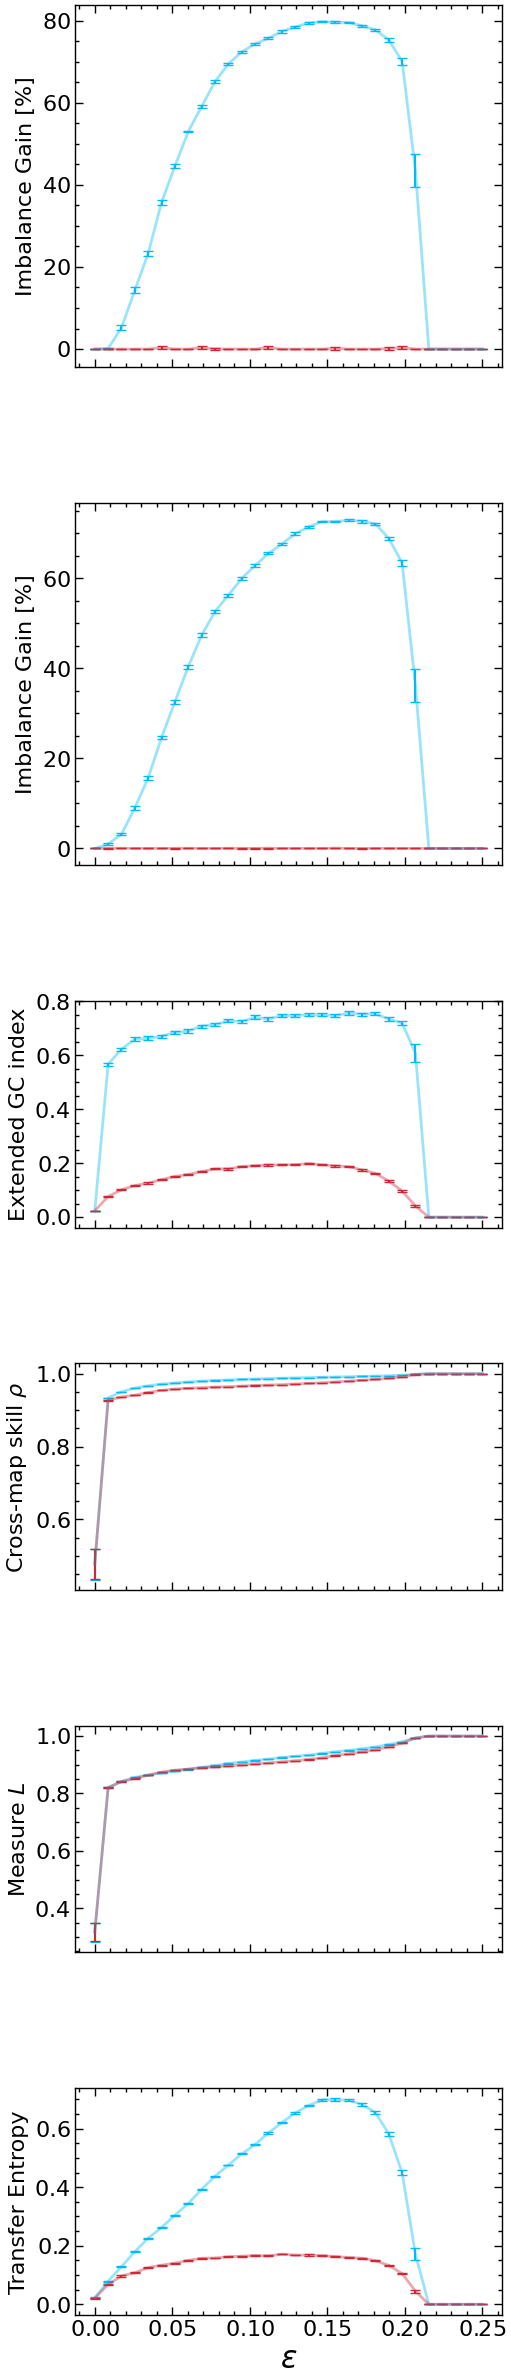

In [6]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(6,1,figsize=(5.5,30), gridspec_kw={'height_ratios': [1.6,1.6,1.0,1.0,1.0,1.0],'hspace': 0.5})

ax[0].errorbar(epsilons, IGs_X_to_Y, IGs_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, IGs_Y_to_X, IGs_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, IGs_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, IGs_Y_to_X, '-', color=colors[1], alpha=0.4)
ax[0].set(ylabel="Imbalance Gain [%]")
ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, IGs_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
ax[1].set(ylabel="Imbalance Gain [%]")
ax[1].axes.xaxis.set_ticklabels([])

ax[2].errorbar(epsilons, egc_index_X_to_Y_avg, egc_index_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].errorbar(epsilons, egc_index_Y_to_X_avg, egc_index_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].plot(epsilons, egc_index_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[2].plot(epsilons, egc_index_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
ax[2].set(ylabel="Extended GC index")
ax[2].axes.xaxis.set_ticklabels([])

ax[3].errorbar(epsilons, ccm_X_to_Y_avg, ccm_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].errorbar(epsilons, ccm_Y_to_X_avg, ccm_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].plot(epsilons, ccm_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[3].plot(epsilons, ccm_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
ax[3].set(ylabel="Cross-map skill $\\rho$")
ax[3].axes.xaxis.set_ticklabels([])

ax[4].errorbar(epsilons, L_X_to_Y_avg, L_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].errorbar(epsilons, L_Y_to_X_avg, L_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].plot(epsilons, L_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[4].plot(epsilons, L_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
ax[4].set(ylabel="Measure $L$")
ax[4].axes.xaxis.set_ticklabels([])

ax[5].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[5].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[5].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[5].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
ax[5].set(ylabel="Transfer Entropy")
ax[5].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig("./figures/rossler_id_with_TE.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Rossler, different

In [7]:
epsilons = np.linspace(0.,0.25,30)
Ls = np.linspace(100,20000,50,dtype=int) # for CCM
alphas = np.linspace(0.,0.25,50) # for IG
nseeds = 20
k_te = 3 # for transfer entropy
minzero = False # for transfer entropy

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/rossler_diff/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/rossler_diff/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(epsilons)))
egc_index_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    egc_index_X_to_Y[seed], egc_index_Y_to_X[seed] = pickle.load(open(f"./extended_gc/pickles/rossler_diff/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# CCM
ccm_X_to_Y = np.zeros((nseeds,len(epsilons),len(Ls)))
ccm_Y_to_X = np.zeros((nseeds,len(epsilons),len(Ls)))
for seed in range(nseeds):
    ccm_X_to_Y[seed], ccm_Y_to_X[seed] = pickle.load(open(f"./ccm/pickles/rossler_diff/seed{seed}.p","rb"))
ccm_X_to_Y_avg = ccm_X_to_Y.mean(axis=0)[:,-1]
ccm_X_to_Y_err = ccm_X_to_Y.std(axis=0)[:,-1] / np.sqrt(nseeds)
ccm_Y_to_X_avg = ccm_Y_to_X.mean(axis=0)[:,-1]
ccm_Y_to_X_err = ccm_Y_to_X.std(axis=0)[:,-1] / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(epsilons)))
L_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    L_X_to_Y[seed], L_Y_to_X[seed] = pickle.load(open(f"./measure_L/pickles/rossler_diff/seed{seed}.p","rb"))
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# transfer entropy, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(
        open(f"../../transfer_entropy/embeddings/pickles/rossler_diff/seed{seed}_k{k_te}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])

In [8]:
# false positive detections in direction Y -> X
mask = epsilons < 0.18

fpd_imb_Y_to_X = (compute_t_stat(IGs_Y_to_X[mask], IGs_Y_to_X_err[mask]) > t_19).sum()
fpd_imb_emb_Y_to_X = (compute_t_stat(IGs_Y_to_X_emb[mask], IGs_Y_to_X_err_emb[mask]) > t_19).sum()
fpd_egc_Y_to_X = (compute_t_stat(egc_index_Y_to_X_avg[mask], egc_index_Y_to_X_err[mask]) > t_19).sum()
fpd_ccm_Y_to_X = (compute_t_stat(ccm_Y_to_X_avg[mask], ccm_Y_to_X_err[mask]) > t_19).sum()
fpd_L_Y_to_X = (compute_t_stat(L_Y_to_X_avg[mask], L_Y_to_X_err[mask]) > t_19).sum()
fpd_te_Y_to_X = (compute_t_stat(TE_mean_Y_to_X_emb[mask], TE_err_Y_to_X_emb[mask]) > t_19).sum()

print("Number and % of false positive detections:")
print(f"IG:\t{fpd_imb_Y_to_X}\t{100*fpd_imb_Y_to_X/len(epsilons[mask]):.2f}")
print(f"IGemb:\t{fpd_imb_emb_Y_to_X}\t{100*fpd_imb_emb_Y_to_X/len(epsilons[mask]):.2f}")
print(f"egc:\t{fpd_egc_Y_to_X}\t{100*fpd_egc_Y_to_X/len(epsilons[mask]):.2f}")
print(f"ccm:\t{fpd_ccm_Y_to_X}\t{100*fpd_ccm_Y_to_X/len(epsilons[mask]):.2f}")
print(f"L:\t{fpd_L_Y_to_X}\t{100*fpd_L_Y_to_X/len(epsilons[mask]):.2f}")
print(f"TE:\t{fpd_te_Y_to_X}\t{100*fpd_te_Y_to_X/len(epsilons[mask]):.2f}\n")
print(f"Number of espilons considered: {len(epsilons[mask])}")


Number and % of false positive detections:
IG:	0	0.00
IGemb:	0	0.00
egc:	21	100.00
ccm:	20	95.24
L:	20	95.24
TE:	21	100.00

Number of espilons considered: 21


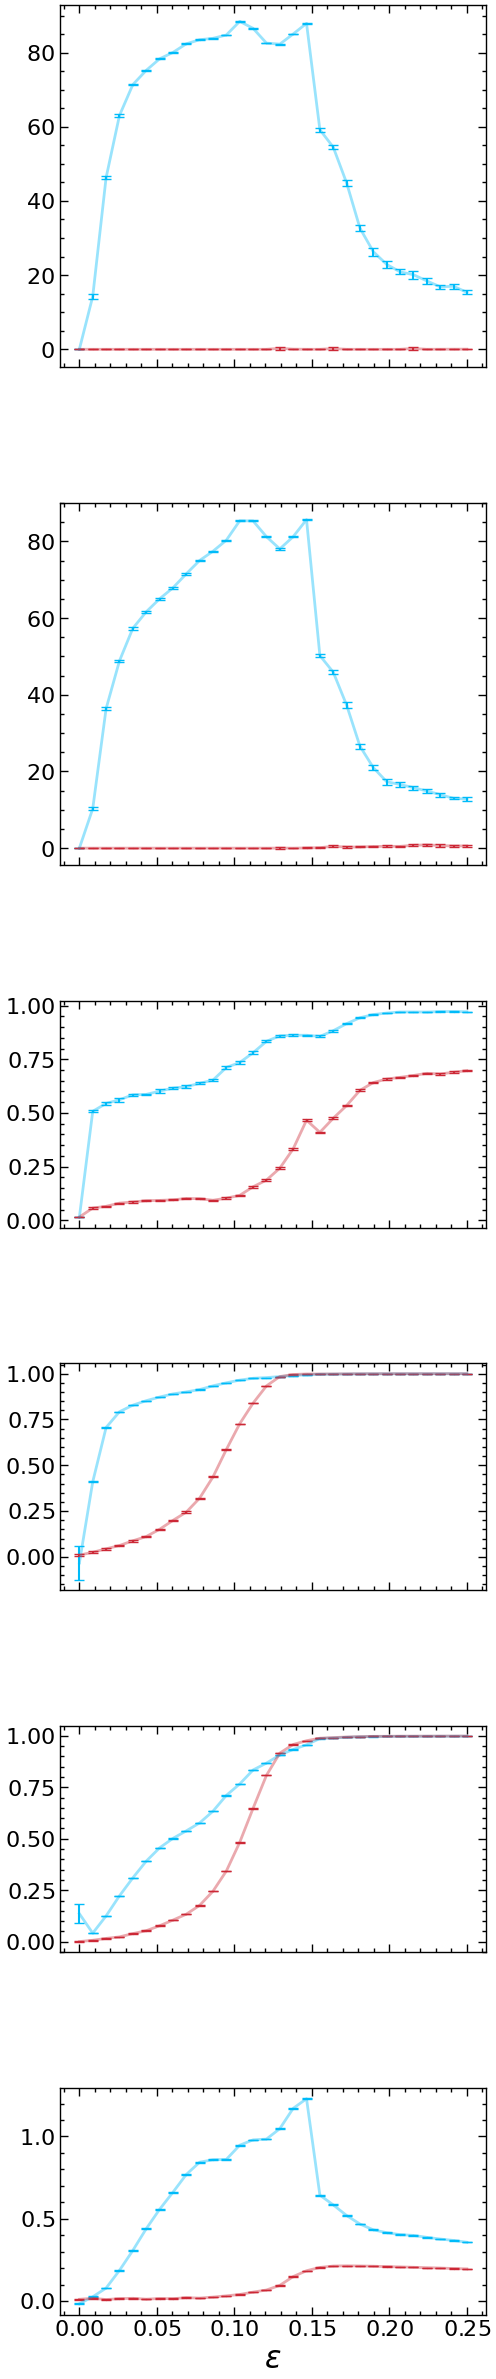

In [9]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(6,1,figsize=(5.5,30), gridspec_kw={'height_ratios': [1.6,1.6,1.0,1.0,1.0,1.0],'hspace': 0.5})

ax[0].errorbar(epsilons, IGs_X_to_Y, IGs_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, IGs_Y_to_X, IGs_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, IGs_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, IGs_Y_to_X, '-', color=colors[1], alpha=0.4)
#ax[0].set(ylabel="Imbalance Gain [%]")
ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, IGs_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Imbalance Gain [%]")
ax[1].axes.xaxis.set_ticklabels([])

ax[2].errorbar(epsilons, egc_index_X_to_Y_avg, egc_index_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].errorbar(epsilons, egc_index_Y_to_X_avg, egc_index_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].plot(epsilons, egc_index_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[2].plot(epsilons, egc_index_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[2].set(ylabel="Extended GC index")
ax[2].axes.xaxis.set_ticklabels([])

ax[3].errorbar(epsilons, ccm_X_to_Y_avg, ccm_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].errorbar(epsilons, ccm_Y_to_X_avg, ccm_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].plot(epsilons, ccm_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[3].plot(epsilons, ccm_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[3].set(ylabel="Cross-map skill $\\rho$")
ax[3].axes.xaxis.set_ticklabels([])

ax[4].errorbar(epsilons, L_X_to_Y_avg, L_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].errorbar(epsilons, L_Y_to_X_avg, L_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].plot(epsilons, L_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[4].plot(epsilons, L_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[4].set(ylabel="Measure $L$")
ax[4].axes.xaxis.set_ticklabels([])

ax[5].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[5].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[5].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[5].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[5].set(ylabel="Transfer Entropy")
ax[5].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig("./figures/rossler_diff_with_TE.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Lorenz

In [10]:
epsilons = np.linspace(0.,0.3,31)
Ls = np.linspace(100,40000,50,dtype=int) # for CCM
alphas = np.linspace(0.,0.3,50) # for IG
k_te = 3 # for transfer entropy
minzero = False # for transfer entropy

selected_seeds = np.delete(np.arange(26),[2,4,5,6,15,23])
nseeds = len(selected_seeds)
print(f"Number of independent realizations: {nseeds}")

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for i_seed,seed in enumerate(selected_seeds):#range(nseeds):
    info_imbalances_X_to_Y[i_seed], info_imbalances_Y_to_X[i_seed] = pickle.load(open(f"./ig_allcoords/pickles/lorenz/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)

IGs_X_to_Y_indep = compute_indep_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X_indep = compute_indep_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas))) 
for i_seed,seed in enumerate(selected_seeds):#range(nseeds):
    info_imbalances_X_to_Y_emb[i_seed], info_imbalances_Y_to_X_emb[i_seed] = pickle.load(open(f"./ig_embeddings/pickles/lorenz/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)

IGs_X_to_Y_emb_indep = compute_indep_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb_indep = compute_indep_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(epsilons)))
egc_index_Y_to_X = np.zeros((nseeds,len(epsilons)))
for i_seed,seed in enumerate(selected_seeds):#range(nseeds):
    egc_index_X_to_Y[i_seed], egc_index_Y_to_X[i_seed] = pickle.load(open(f"./extended_gc/pickles/lorenz/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# CCM
ccm_X_to_Y = np.zeros((nseeds,len(epsilons),len(Ls)))
ccm_Y_to_X = np.zeros((nseeds,len(epsilons),len(Ls)))
for i_seed,seed in enumerate(selected_seeds):#range(nseeds):
    ccm_X_to_Y[i_seed], ccm_Y_to_X[i_seed] = pickle.load(open(f"./ccm/pickles/lorenz/seed{seed}.p","rb"))
ccm_X_to_Y_avg = ccm_X_to_Y.mean(axis=0)[:,-1]
ccm_X_to_Y_err = ccm_X_to_Y.std(axis=0)[:,-1] / np.sqrt(nseeds)
ccm_Y_to_X_avg = ccm_Y_to_X.mean(axis=0)[:,-1]
ccm_Y_to_X_err = ccm_Y_to_X.std(axis=0)[:,-1] / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(epsilons)))
L_Y_to_X = np.zeros((nseeds,len(epsilons)))
for i_seed,seed in enumerate(selected_seeds):#range(nseeds):
    L_X_to_Y[i_seed], L_Y_to_X[i_seed] = pickle.load(open(f"./measure_L/pickles/lorenz/seed{seed}.p","rb"))
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# transfer entropy, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(
        open(f"../../transfer_entropy/embeddings/pickles/lorenz/seed{seed}_k{k_te}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])

Number of independent realizations: 20


(20, 31, 50)
(20, 31, 50)
(20, 31, 50)
(20, 31, 50)


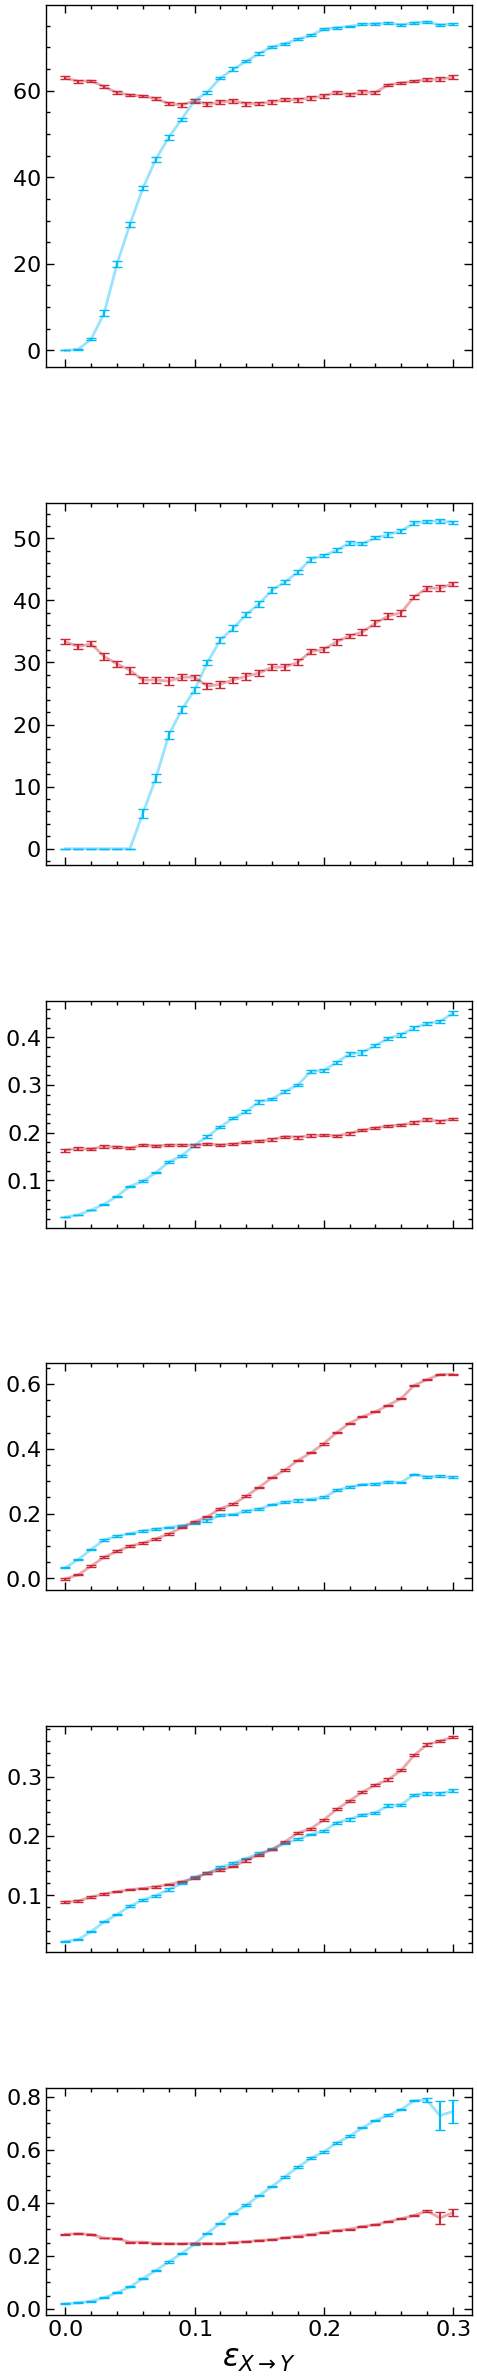

In [11]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(6,1,figsize=(5.5,30), gridspec_kw={'height_ratios': [1.6,1.6,1.0,1.0,1.0,1.0],'hspace': 0.5})

ax[0].errorbar(epsilons, IGs_X_to_Y, IGs_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].errorbar(epsilons, IGs_Y_to_X, IGs_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[0].plot(epsilons, IGs_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, IGs_Y_to_X, '-', color=colors[1], alpha=0.4)
#ax[0].set(ylabel="Imbalance Gain [%]")
ax[0].axes.xaxis.set_ticklabels([])

ax[1].errorbar(epsilons, IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, IGs_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Imbalance Gain [%]")
ax[1].axes.xaxis.set_ticklabels([])

ax[2].errorbar(epsilons, egc_index_X_to_Y_avg, egc_index_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].errorbar(epsilons, egc_index_Y_to_X_avg, egc_index_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].plot(epsilons, egc_index_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[2].plot(epsilons, egc_index_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[2].set(ylabel="Extended GC index")
ax[2].axes.xaxis.set_ticklabels([])

ax[3].errorbar(epsilons, ccm_X_to_Y_avg, ccm_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].errorbar(epsilons, ccm_Y_to_X_avg, ccm_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].plot(epsilons, ccm_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[3].plot(epsilons, ccm_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[3].set(ylabel="Cross-map skill $\\rho$")
ax[3].axes.xaxis.set_ticklabels([])

ax[4].errorbar(epsilons, L_X_to_Y_avg, L_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].errorbar(epsilons, L_Y_to_X_avg, L_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].plot(epsilons, L_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[4].plot(epsilons, L_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[4].set(ylabel="Measure $L$")
ax[4].axes.xaxis.set_ticklabels([])

ax[5].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[5].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[5].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[5].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[5].set(ylabel="Transfer Entropy")
ax[5].set_xlabel("$\\varepsilon_{X\\rightarrow Y}$", fontsize=22)

plt.savefig("./figures/lorenz_with_TE.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Lorenz 96

In [12]:
epsilons = np.linspace(0.,1.5,31)
Ls = np.linspace(100,50000,50,dtype=int) # for CCM
alphas = np.linspace(0.,1.5,50) # for IG
nseeds = 20
k_te = 3 # for transfer entropy
minzero = False # for transfer entropy

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y[seed], info_imbalances_Y_to_X[seed] = pickle.load(open(f"./ig_allcoords/pickles/lorenz96/seed{seed}.p","rb"))
IGs_X_to_Y, IGs_X_to_Y_err = compute_IGs(info_imbalances_X_to_Y)
IGs_Y_to_X, IGs_Y_to_X_err = compute_IGs(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((nseeds,len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((nseeds,len(epsilons),len(alphas))) 
for seed in range(nseeds):
    info_imbalances_X_to_Y_emb[seed], info_imbalances_Y_to_X_emb[seed] = pickle.load(open(f"./ig_embeddings/pickles/lorenz96/seed{seed}.p","rb"))
IGs_X_to_Y_emb, IGs_X_to_Y_err_emb = compute_IGs(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb, IGs_Y_to_X_err_emb = compute_IGs(info_imbalances_Y_to_X_emb)

# EGC
egc_index_X_to_Y = np.zeros((nseeds,len(epsilons)))
egc_index_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    egc_index_X_to_Y[seed], egc_index_Y_to_X[seed] = pickle.load(open(f"./extended_gc/pickles/lorenz96/seed{seed}.p","rb"))
egc_index_X_to_Y_avg = egc_index_X_to_Y.mean(axis=0)
egc_index_X_to_Y_err = egc_index_X_to_Y.std(axis=0) / np.sqrt(nseeds)
egc_index_Y_to_X_avg = egc_index_Y_to_X.mean(axis=0)
egc_index_Y_to_X_err = egc_index_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# CCM
ccm_X_to_Y = np.zeros((nseeds,len(epsilons),len(Ls)))
ccm_Y_to_X = np.zeros((nseeds,len(epsilons),len(Ls)))
for seed in range(nseeds):
    ccm_X_to_Y[seed], ccm_Y_to_X[seed] = pickle.load(open(f"./ccm/pickles/lorenz96/seed{seed}.p","rb"))
ccm_X_to_Y_avg = ccm_X_to_Y.mean(axis=0)[:,-1]
ccm_X_to_Y_err = ccm_X_to_Y.std(axis=0)[:,-1] / np.sqrt(nseeds)
ccm_Y_to_X_avg = ccm_Y_to_X.mean(axis=0)[:,-1]
ccm_Y_to_X_err = ccm_Y_to_X.std(axis=0)[:,-1] / np.sqrt(nseeds)

# measure L
L_X_to_Y = np.zeros((nseeds,len(epsilons)))
L_Y_to_X = np.zeros((nseeds,len(epsilons)))
for seed in range(nseeds):
    L_X_to_Y[seed], L_Y_to_X[seed] = pickle.load(open(f"./measure_L/pickles/lorenz96/seed{seed}.p","rb"))
L_X_to_Y_avg = L_X_to_Y.mean(axis=0)
L_X_to_Y_err = L_X_to_Y.std(axis=0) / np.sqrt(nseeds)
L_Y_to_X_avg = L_Y_to_X.mean(axis=0)
L_Y_to_X_err = L_Y_to_X.std(axis=0) / np.sqrt(nseeds)

# transfer entropy, embeddings
transfer_entropies_X_to_Y_emb = np.zeros((nseeds,len(epsilons)))
transfer_entropies_Y_to_X_emb = np.zeros((nseeds,len(epsilons))) 
for seed in range(nseeds):
    transfer_entropies_X_to_Y_emb[seed], transfer_entropies_Y_to_X_emb[seed] = pickle.load(
        open(f"../../transfer_entropy/embeddings/pickles/lorenz96/seed{seed}_k{k_te}_minzero{minzero}.p","rb"))
TE_mean_X_to_Y_emb = transfer_entropies_X_to_Y_emb.mean(axis=0)
TE_err_X_to_Y_emb= transfer_entropies_X_to_Y_emb.std(axis=0) / np.sqrt(transfer_entropies_X_to_Y_emb.shape[0])
TE_mean_Y_to_X_emb = transfer_entropies_Y_to_X_emb.mean(axis=0)
TE_err_Y_to_X_emb= transfer_entropies_Y_to_X_emb.std(axis=0) / np.sqrt(transfer_entropies_Y_to_X_emb.shape[0])

In [13]:
# false positive detections in direction Y->X
fpd_imb_Y_to_X = (compute_t_stat(IGs_Y_to_X, IGs_Y_to_X_err) > t_19).sum()
fpd_imb_emb_Y_to_X = (compute_t_stat(IGs_Y_to_X_emb, IGs_Y_to_X_err_emb) > t_19).sum()
fpd_egc_Y_to_X = (compute_t_stat(egc_index_Y_to_X_avg, egc_index_Y_to_X_err) > t_19).sum()
fpd_ccm_Y_to_X = (compute_t_stat(ccm_Y_to_X_avg, ccm_Y_to_X_err) > t_19).sum()
fpd_L_Y_to_X = (compute_t_stat(L_Y_to_X_avg, L_Y_to_X_err) > t_19).sum()
fpd_te_Y_to_X = (compute_t_stat(TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb) > t_19).sum()

print("Number and % of false positive detections:\n")
print(f"IG:\t{fpd_imb_Y_to_X}\t{fpd_imb_Y_to_X/len(epsilons)}")
print(f"IGemb:\t{fpd_imb_emb_Y_to_X}\t{fpd_imb_emb_Y_to_X/len(epsilons)}")
print(f"egc:\t{fpd_egc_Y_to_X}\t{fpd_egc_Y_to_X/len(epsilons)}")
print(f"ccm:\t{fpd_ccm_Y_to_X}\t{fpd_ccm_Y_to_X/len(epsilons)}")
print(f"L:\t{fpd_L_Y_to_X}\t{fpd_L_Y_to_X/len(epsilons)}")
print(f"TE:\t{fpd_te_Y_to_X}\t{100*fpd_te_Y_to_X/len(epsilons):.2f}\n")
print(f"Number of espilons considered: {len(epsilons)}\n")

# positions of epsilons of false positive detections, to find a common one
print("Positions of epsilons of fpd:")
print(f"IG:\t{np.where(compute_t_stat(IGs_Y_to_X, IGs_Y_to_X_err) > t_19)[0]}")
print(f"IGemb:\t{np.where(compute_t_stat(IGs_Y_to_X_emb, IGs_Y_to_X_err_emb) > t_19)[0]}")
print(f"egc:\t{np.where(compute_t_stat(egc_index_Y_to_X_avg, egc_index_Y_to_X_err) > t_19)[0]}")
print(f"ccm:\t{np.where(compute_t_stat(ccm_Y_to_X_avg, ccm_Y_to_X_err) > t_19)[0]}")
print(f"L:\t{np.where(compute_t_stat(L_Y_to_X_avg, L_Y_to_X_err) > t_19)[0]}")
print(f"L:\t{np.where(compute_t_stat(TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb) > t_19)[0]}")

Number and % of false positive detections:

IG:	3	0.0967741935483871
IGemb:	4	0.12903225806451613
egc:	31	1.0
ccm:	30	0.967741935483871
L:	30	0.967741935483871
TE:	31	100.00

Number of espilons considered: 31

Positions of epsilons of fpd:
IG:	[16 24 27]
IGemb:	[ 9 15 17 21]
egc:	[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]
ccm:	[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30]
L:	[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30]
L:	[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30]


In [14]:
ieps = 9
epsilons_test = epsilons[ieps]

print(f"Relative differences X->Y and Y->X for epsilon = {epsilons_test}:")
print(f"IG:\t{(IGs_X_to_Y[ieps] / IGs_Y_to_X[ieps])}")
print(f"IGemb:\t{(IGs_X_to_Y_emb[ieps] / IGs_Y_to_X_emb[ieps])}")
print(f"egc:\t{(egc_index_X_to_Y_avg[ieps] / egc_index_Y_to_X_avg[ieps])}")
print(f"ccm:\t{(ccm_X_to_Y_avg[ieps] / ccm_Y_to_X_avg[ieps])}")
print(f"L:\t{(L_X_to_Y_avg[ieps] / L_Y_to_X_avg[ieps])}")
print(f"TE:\t{(TE_mean_X_to_Y_emb[ieps] / TE_mean_Y_to_X_emb[ieps])}")

Relative differences X->Y and Y->X for epsilon = 0.45:
IG:	178.31728626528778
IGemb:	21.75224137303966
egc:	1.216274624695837
ccm:	1.5164850951009208
L:	1.2059883163746585
TE:	2.1011491450847104


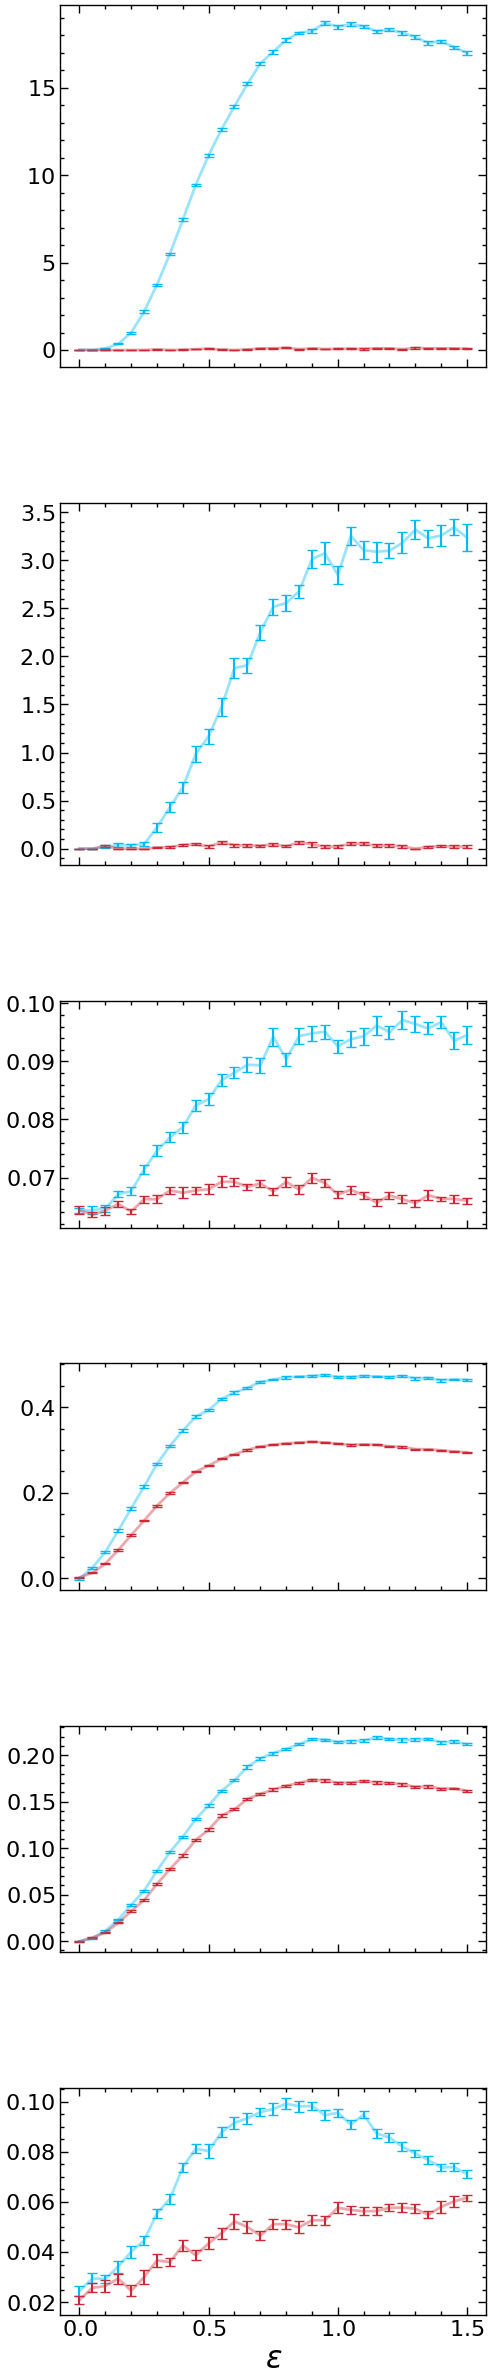

In [15]:
plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(6,1,figsize=(5.5,30), gridspec_kw={'height_ratios': [1.6,1.6,1.0,1.0,1.0,1.0],'hspace': 0.5})

ax[0].errorbar(epsilons, IGs_X_to_Y, IGs_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1, label="$X\\rightarrow Y$")
ax[0].errorbar(epsilons, IGs_Y_to_X, IGs_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1, label="$Y\\rightarrow X$")
ax[0].plot(epsilons, IGs_X_to_Y, '-', color=colors[0], alpha=0.4)
ax[0].plot(epsilons, IGs_Y_to_X, '-', color=colors[1], alpha=0.4)
#ax[0].set(ylabel="Imbalance Gain [%]")
ax[0].axes.xaxis.set_ticklabels([])
#ax[0].legend(loc="center right")

ax[1].errorbar(epsilons, IGs_X_to_Y_emb, IGs_X_to_Y_err_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].errorbar(epsilons, IGs_Y_to_X_emb, IGs_Y_to_X_err_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[1].plot(epsilons, IGs_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[1].plot(epsilons, IGs_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[1].set(ylabel="Imbalance Gain [%]")
ax[1].axes.xaxis.set_ticklabels([])

ax[2].errorbar(epsilons, egc_index_X_to_Y_avg, egc_index_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].errorbar(epsilons, egc_index_Y_to_X_avg, egc_index_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[2].plot(epsilons, egc_index_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[2].plot(epsilons, egc_index_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[2].set(ylabel="Extended GC index")
ax[2].axes.xaxis.set_ticklabels([])

ax[3].errorbar(epsilons, ccm_X_to_Y_avg, ccm_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].errorbar(epsilons, ccm_Y_to_X_avg, ccm_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[3].plot(epsilons, ccm_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[3].plot(epsilons, ccm_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[3].set(ylabel="Cross-map skill $\\rho$")
ax[3].axes.xaxis.set_ticklabels([])

ax[4].errorbar(epsilons, L_X_to_Y_avg, L_X_to_Y_err, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].errorbar(epsilons, L_Y_to_X_avg, L_Y_to_X_err, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[4].plot(epsilons, L_X_to_Y_avg, '-', color=colors[0], alpha=0.4)
ax[4].plot(epsilons, L_Y_to_X_avg, '-', color=colors[1], alpha=0.4)
#ax[4].set(ylabel="Measure $L$")
ax[4].axes.xaxis.set_ticklabels([])

ax[5].errorbar(epsilons, TE_mean_X_to_Y_emb, TE_err_X_to_Y_emb, fmt='.', markersize=0.1, color=colors[0], capsize=3.5, elinewidth=1.5, capthick=1)
ax[5].errorbar(epsilons, TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb, fmt='.', markersize=0.1, color=colors[1], capsize=3.5, elinewidth=1.5, capthick=1)
ax[5].plot(epsilons, TE_mean_X_to_Y_emb, '-', color=colors[0], alpha=0.4)
ax[5].plot(epsilons, TE_mean_Y_to_X_emb, '-', color=colors[1], alpha=0.4)
#ax[5].set(ylabel="Transfer Entropy")
ax[5].set_xlabel("$\\varepsilon$", fontsize=22)

plt.savefig("./figures/lorenz96_with_TE.pdf", dpi=300, bbox_inches='tight')
plt.show()

### Compute FPR vs threshold for Lorenz 96

In [16]:
ts = np.array([0.,0.688,0.861,1.066,1.328,1.729,2.093,2.539,2.861,3.579,3.883])
ps = np.array([0.5,0.25,0.2,0.15,0.10,0.05,0.025,0.01,0.005,0.001,0.0005])

In [17]:
fpd_imb_Y_to_X = []
fpd_imb_emb_Y_to_X = []
fpd_egc_Y_to_X = []
fpd_ccm_Y_to_X = []
fpd_L_Y_to_X = []
fpd_TE_Y_to_X = []

for i,t in enumerate(ts):
    fpd_imb_Y_to_X.append( 100*(compute_t_stat(IGs_Y_to_X, IGs_Y_to_X_err) > t).sum() / len(epsilons))
    fpd_imb_emb_Y_to_X.append( 100*(compute_t_stat(IGs_Y_to_X_emb, IGs_Y_to_X_err_emb) > t).sum() / len(epsilons))
    fpd_egc_Y_to_X.append( 100*(compute_t_stat(egc_index_Y_to_X_avg, egc_index_Y_to_X_err) > t).sum() / len(epsilons))
    fpd_ccm_Y_to_X.append( 100*(compute_t_stat(ccm_Y_to_X_avg, ccm_Y_to_X_err) > t).sum() / len(epsilons))
    fpd_L_Y_to_X.append( 100*(compute_t_stat(L_Y_to_X_avg, L_Y_to_X_err) > t).sum() / len(epsilons))
    fpd_TE_Y_to_X.append( 100*(compute_t_stat(TE_mean_Y_to_X_emb, TE_err_Y_to_X_emb) > t).sum() / len(epsilons))

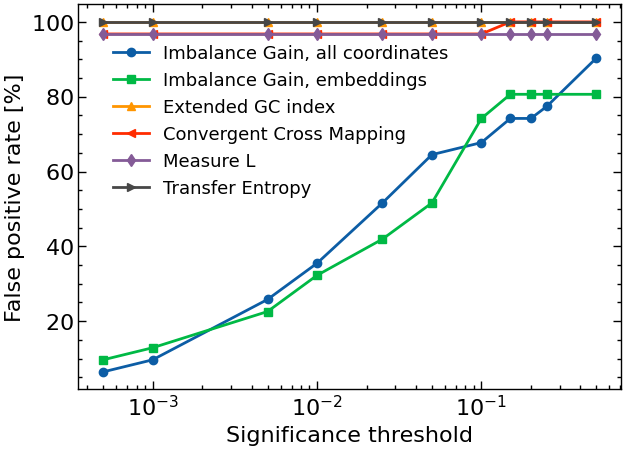

In [18]:
plt.rcParams['font.size'] = 14
plt.figure(figsize=(7,5))
plt.plot(ps, fpd_imb_Y_to_X, 'o-', label="Imbalance Gain, all coordinates")
plt.plot(ps, fpd_imb_emb_Y_to_X, 's-', label="Imbalance Gain, embeddings")
plt.plot(ps, fpd_egc_Y_to_X, '^-', label="Extended GC index")
plt.plot(ps, fpd_ccm_Y_to_X, '<-', label="Convergent Cross Mapping")
plt.plot(ps, fpd_L_Y_to_X, 'd-', label="Measure L")
plt.plot(ps, fpd_TE_Y_to_X, '>-', label="Transfer Entropy")
plt.xlabel("Significance threshold")
plt.ylabel("False positive rate [%]")
plt.xscale("log")
plt.legend(loc=[0.05,0.48], fontsize=13)
plt.savefig("./figures/FPR_vs_threshold_with_TE.pdf", dpi=300, bbox_inches='tight')
plt.show()